In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('dark_background')
COLORS = ['#00d4ff', '#ff007f', '#39ff14', '#ffd700']
LOGS_FILE = "../evaluation/reports/rl_episode_logs.json"

## 1. Identify Failure Modes

In [6]:
with open(LOGS_FILE, 'r') as f:
    logs = json.load(f)

dqn_logs = logs.get('DQN', [])
failures = [ep for ep in dqn_logs if not ep['success']]
sla_breaches = [ep for ep in dqn_logs if ep['sla_breach']]

print(f"Total Evaluation Episodes: {len(dqn_logs)}")
print(f"Total Failures: {len(failures)}")
print(f"Total SLA Breaches: {len(sla_breaches)}")

Total Evaluation Episodes: 200
Total Failures: 35
Total SLA Breaches: 13


## 2. Root Cause Analysis (Drill Down)

In [7]:
if failures:
    sample_fail = failures[0]
    print("Sample Failure Trace")
    print("="*30)
    for step in sample_fail['history']:
        print(f"Step {step['step']}: Action='{step['action_name']}' | Reward={step['reward']:.2f}")
        print(f"  -> Frustration: {step['info']['frustration']:.2f}")
else:
    print("No failures found in the evaluation slice.")

Sample Failure Trace
Step 0: Action='suggest_top1' | Reward=-1.90
  -> Frustration: 0.27
Step 1: Action='suggest_top1' | Reward=-1.90
  -> Frustration: 0.42
Step 2: Action='suggest_top1' | Reward=-1.90
  -> Frustration: 0.57
Step 3: Action='suggest_top1' | Reward=-1.90
  -> Frustration: 0.72
Step 4: Action='suggest_top1' | Reward=-1.90
  -> Frustration: 0.87


## 3. Failure Categories

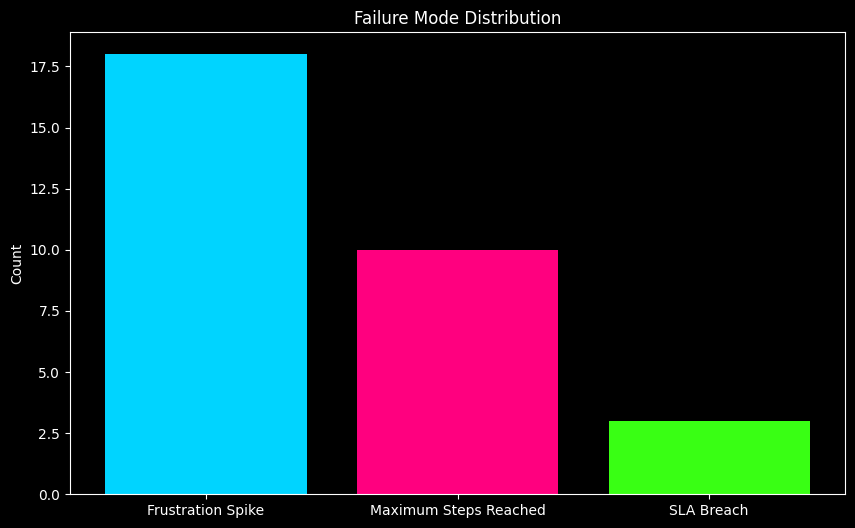

In [8]:
categories = {
    "Frustration Spike": 0,
    "Maximum Steps Reached": 0,
    "SLA Breach": 0
}

for fail in failures:
    if fail['steps'] >= 6:
        categories["Maximum Steps Reached"] += 1
    if fail['sla_breach']:
        categories["SLA Breach"] += 1
    if any(h['info']['frustration'] > 0.8 for h in fail['history']):
        categories["Frustration Spike"] += 1

plt.figure(figsize=(10, 6))
plt.bar(categories.keys(), categories.values(), color=COLORS)
plt.title("Failure Mode Distribution")
plt.ylabel("Count")
plt.show()